# Postituse tasemel mudelite võrdlus


In [1]:
%pip install scikit-learn
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import json
import time
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from openai import OpenAI
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.special import softmax


TARGET = "HubSpot"

c:\Users\annmarle\Desktop\Redditi postituste automaatne klassifitseerimine erineva signaalitasemega keskkondades\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Meelestatus

## Andmete lugemine


In [3]:
low = pd.read_json("../data/cleaned_data/low_clean.json")
high = pd.read_json("../data/cleaned_data/high_clean.json")

low["source_set"] = "low"
high["source_set"] = "high"

data = pd.concat([low, high], ignore_index=True)

# kasutame ainult postituse taset
data = data.dropna(subset=["clean_post_text"]).copy()
data["clean_post_text"] = data["clean_post_text"].astype(str).str.strip()
data = data[data["clean_post_text"] != ""].reset_index(drop=True)


In [4]:
data[["id", "subreddit_name", "source_set", "clean_post_text"]].head(5)

,id,subreddit_name,source_set,clean_post_text
0,1rt6kxz,marketing,low,How do you manage conference event ROI? Our co...
1,1r94q3j,marketing,low,Struggling with HubSpot mobile optimization on...
2,1r8b32m,marketing,low,"Marketing ,Sales alignment is killing me. Anyo..."
3,1quofd6,marketing,low,Hubspot vs. Meta Tracking Hello dear marketers...
4,1q7l645,marketing,low,HubSpot requirements everywhere in B2B - how d...


## Mudelid

In [5]:
tokenizer_overall = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
model_overall = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")

tokenizer_topic = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-topic-sentiment-latest")
model_topic = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-topic-sentiment-latest")

labels_sentiment = ["negative", "neutral", "positive"]
labels_topic = ["strongly negative", "negative", "negative or neutral", "positive", "strongly positive"]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 350.26it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 483.62it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-topic-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.p

## Meelestatuse määramine

In [6]:
def predict_overall_sentiment(text):
    inputs = tokenizer_overall(text, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model_overall(**inputs)

    probs = outputs.logits[0].detach().numpy()
    probs = softmax(probs)

    sentiment_index = int(np.argmax(probs))

    return {
        "overall_label": labels_sentiment[sentiment_index],
        "overall_negative": float(probs[0]),
        "overall_neutral": float(probs[1]),
        "overall_positive": float(probs[2]),
    }


def predict_topic_sentiment(text, target):
    combined = f"{text} </s> {target}"
    inputs = tokenizer_topic(combined, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = model_topic(**inputs)

    probs = outputs.logits[0].detach().numpy()
    probs = softmax(probs)

    sentiment_index = int(np.argmax(probs))

    return {
        "topic_label": labels_topic[sentiment_index],
        "topic_strongly_negative": float(probs[0]),
        "topic_negative": float(probs[1]),
        "topic_negative_or_neutral": float(probs[2]),
        "topic_positive": float(probs[3]),
        "topic_strongly_positive": float(probs[4]),
    }

In [7]:
from dotenv import load_dotenv
import os

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [ ]:
def llm_sentiment(text, target, subreddit):

    prompt = f'''
        You are analyzing Reddit posts about companies.

        Target company: {target}
        Subreddit: {subreddit}
        Post: {text}

        Your task is to classify the sentiment of the post toward {target} as: "positive", "negative", or "neutral".

        If the post is from a subreddit dedicated to the company, assume it is about {target}, even if the name is not directly mentioned.

        Focus on what the author actually thinks about {target}, not just the general tone of the text.

        Use these guidelines:
        - "positive" - the author is clearly satisfied, happy, or says something good about {target}
        - "negative" - the author complains, expresses frustration, or describes a problem related to {target}
        - "neutral" - the post mainly asks a question, shares information, or starts a discussion without a clear opinion

        Questions are usually neutral, unless they clearly describe a problem or frustration related to {target}.  
        A positive or enthusiastic tone alone does not necessarily mean positive sentiment.

        If there is no clear opinion about {target}, choose "neutral".

        Return only this JSON:
        {{
            "sentiment": "positive" | "negative" | "neutral",
            "confidence": 0.0,
            "reasoning": "one short explanation"
        }}
'''
    try: 
        response = client.responses.create(
            model="gpt-4.1-mini",
            input=prompt,
        )

        raw = response.output_text.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()

        analysis = json.loads(raw)
        return analysis
    
    except json.JSONDecodeError as e:
        print("JSON error on:" + response.output_text)
        return{
            "sentiment": "neutral",
            "confidence": 0.0,
            "reasoning": "ERROR: JSON error"
        }


In [ ]:
rows = []

start_time = time.time()

for i, row in data.iterrows():
    text = row["clean_post_text"]

    overall_results = predict_overall_sentiment(text)
    topic_results = predict_topic_sentiment(text, TARGET)

    out = {
        "id": row.get("id"),
        "subreddit_name": row.get("subreddit_name"),
        "source_set": row.get("source_set"),
        "score": row.get("score"),
        "created_utc": row.get("created_utc"),
        "clean_post_text": text,
        **overall_results,
        **topic_results,
    }

    try:
        llm_results = llm_sentiment(text, TARGET, row["subreddit_name"])

        out.update({
            "llm_sentiment": llm_results.get("sentiment", "neutral"),
            "llm_confidence": llm_results.get("confidence", 0.0),
            "llm_reasoning": llm_results.get("reasoning", "")
        })

    except Exception as e:
        out.update({
            "llm_sentiment": "neutral",
            "llm_confidence": 0.0,
            "llm_reasoning": f"ERROR: {e}"
        })

    rows.append(out)

    if (i + 1) % 50 == 0 or (i + 1) == len(data):
        print(i+1)



results = pd.DataFrame(rows)

seconds = time.time() - start_time
print(seconds)

In [ ]:
import os
os.makedirs("../data/sentiment_results", exist_ok=True)
results.to_json("../data/sentiment_results/post_level_results_2.json", orient="records", indent=2, force_ascii=False)
results.to_csv("../data/sentiment_results/post_level_results_2.csv",index=False,encoding="utf-8")

# Tulemuste võrdlus

In [ ]:
results = pd.read_csv("../data/sentiment_results/post_level_results_2.csv")
results.rename(columns={"llm_sentiment": "llm_label"}, inplace=True)
results.columns

Index(['id', 'subreddit_name', 'source_set', 'score', 'created_utc',
       'clean_post_text', 'overall_label', 'overall_negative',
       'overall_neutral', 'overall_positive', 'topic_label',
       'topic_strongly_negative', 'topic_negative',
       'topic_negative_or_neutral', 'topic_positive',
       'topic_strongly_positive', 'llm_label', 'llm_confidence',
       'llm_reasoning'],
      dtype='str')

In [ ]:
results[["id", "subreddit_name", "source_set", "clean_post_text","overall_label", "topic_label", "llm_label"]].head()

,id,subreddit_name,source_set,clean_post_text,overall_label,topic_label,llm_label
0,1rt6kxz,marketing,low,How do you manage conference event ROI? Our co...,neutral,negative or neutral,neutral
1,1r94q3j,marketing,low,Struggling with HubSpot mobile optimization on...,negative,negative or neutral,negative
2,1r8b32m,marketing,low,"Marketing ,Sales alignment is killing me. Anyo...",negative,negative,negative
3,1quofd6,marketing,low,Hubspot vs. Meta Tracking Hello dear marketers...,neutral,negative or neutral,negative
4,1q7l645,marketing,low,HubSpot requirements everywhere in B2B - how d...,neutral,negative or neutral,neutral


### Mudelite meelestatuse jaotuste võrdlustabelid

In [5]:
# Teeme topic based meelestatuse viis klassi kolmeks klassiks

# Võtame "strongly negative" ja "negative" kokku -> "negative"
# Muudame "negative or neutral" -> "neutral"
# Võtame "strongly positive" ja "positive" kokku -> "positive"
def topic_to_3(label):
    if label in ["strongly negative", "negative"]:
        return "negative"
    if label == "negative or neutral":
        return "neutral"
    if label in ["positive", "strongly positive"]:
        return "positive"
    return label

results["topic_label_3class"] = results["topic_label"].apply(topic_to_3)

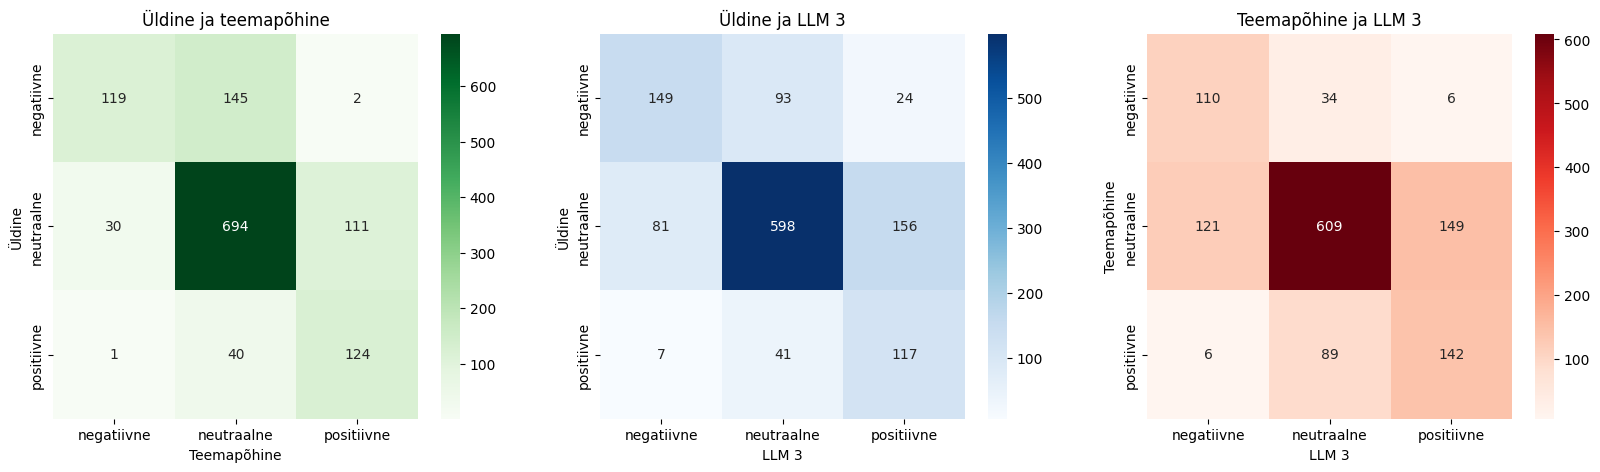

In [6]:
overall_vs_topic = pd.crosstab(results["overall_label"], results["topic_label_3class"])
overall_vs_llm = pd.crosstab(results["overall_label"], results["llm_label"])
topic_vs_llm = pd.crosstab(results["topic_label_3class"], results["llm_label"])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = ["negatiivne", "neutraalne", "positiivne"]

# Üldine ja teemapõhine
sns.heatmap(overall_vs_topic, annot=True, fmt="d",
    cmap="Greens", xticklabels=labels, yticklabels=labels, ax=axes[0])

axes[0].set_title("Üldine ja teemapõhine")
axes[0].set_xlabel("Teemapõhine")
axes[0].set_ylabel("Üldine")


# Üldine ja LLM
sns.heatmap(overall_vs_llm, annot=True, fmt="d",
    cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[1])

axes[1].set_title("Üldine ja LLM 3")
axes[1].set_xlabel("LLM 3")
axes[1].set_ylabel("Üldine")

# Teemapõhine ja LLM
sns.heatmap(topic_vs_llm, annot=True, fmt="d",
    cmap="Reds", xticklabels=labels, yticklabels=labels, ax=axes[2])

axes[2].set_title("Teemapõhine ja LLM 3")
axes[2].set_xlabel("LLM 3")
axes[2].set_ylabel("Teemapõhine")

plt.show();


### Võtame keskmise mudeli meelestatuse postituste pealt

In [7]:
posts_summary_data = pd.DataFrame({
    "overall": [
        (results["overall_label"] == "negative").mean(),
        (results["overall_label"] == "neutral").mean(),
        (results["overall_label"] == "positive").mean(),
    ],
    "topic": [
        (results["topic_label_3class"] == "negative").mean(),
        (results["topic_label_3class"] == "neutral").mean(),
        (results["topic_label_3class"] == "positive").mean(),
    ],
    "llm": [
        (results["llm_label"] == "negative").mean(),
        (results["llm_label"] == "neutral").mean(),
        (results["llm_label"] == "positive").mean(),
    ]
}, index=["negative", "neutral", "positive"])

posts_summary_data


,overall,topic,llm
negative,0.210111,0.118483,0.187204
neutral,0.659558,0.694313,0.578199
positive,0.130332,0.187204,0.234597


In [8]:
table = posts_summary_data.copy()
table.columns = ["Üldine mudel", "Teemapõhine mudel", "LLM (GPT-4.1-mini)"]
table.index = ["Negatiivne", "Neutraalne", "Positiivne"]
table = (table * 100).round(1)
table_display = table.astype(str) + "%"
table_display


,Üldine mudel,Teemapõhine mudel,LLM (GPT-4.1-mini)
Negatiivne,21.0%,11.8%,18.7%
Neutraalne,66.0%,69.4%,57.8%
Positiivne,13.0%,18.7%,23.5%


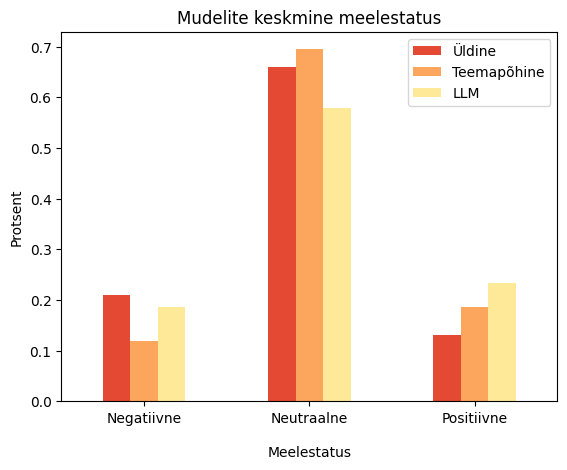

In [9]:

colors = sns.color_palette("RdYlGn", 6) 
posts_summary_data.plot(kind="bar", color=colors, )
plt.xticks(ticks=[0,1,2], labels=["Negatiivne", "Neutraalne", "Positiivne"],rotation=0)
plt.legend(["Üldine", "Teemapõhine", "LLM"])

plt.title("Mudelite keskmine meelestatus")
plt.xlabel("Meelestatus", labelpad=15)
plt.ylabel("Protsent")

plt.show()

## Erinevuste näited

In [10]:
pd.set_option('display.max_colwidth', None)

### overall ja topic

In [17]:
overall_topic_differneces = results[results["overall_label"] != results["topic_label_3class"]].copy()
print("Erinevusi kokku:", overall_topic_differneces.shape[0])

label_order = ["negative", "neutral", "positive"]

pairs = []
samples = []

for overall in label_order:
    for topic in label_order:
        if overall == topic:
            continue
        
        subset = results[
            (results["overall_label"] == overall) &
            (results["topic_label_3class"] == topic)
        ]
        
        if len(subset) > 0:
            sample = subset.sample(1, random_state=42)
            samples.append(sample)

pair_samples_1 = pd.concat(samples)

display(pair_samples_1[[
    "clean_post_text",
    "overall_label",
    "topic_label_3class"
]])

Erinevusi kokku: 329


,clean_post_text,overall_label,topic_label_3class
484,"whats hubspot bad at Hi, thinking about using hubspot, is there anything its not great at? Can automate some things outside of hubspot if its weak in some areas. Thanks!",negative,neutral
1117,"It’s time to actually use HubSpot’s lead capture tools I can’t tell you how many HubSpot portals I’ve opened where the lead capture tools are just sitting there. Forms not connected. Pop-ups disabled. Tracking code missing. And then people wonder why nothing new is coming into their CRM. I mean, you don’t need a huge strategy to start generating leads, you just need to use the basics that are already built in. Here’s where I’d start: * Install the tracking code on every page! * Add a simple form to your highest-traffic page (even a “Request pricing” or “Contact us” form) * Test out the meeting widget * Try one pop-up or slide-in with a clear helpful offer * Track what’s actually converting, not just what’s getting clicks. These are very easy tools to set up and use but they can make a huge difference. You’d be surprised how much growth comes from simply turning on what you already have. As someone who used to work at HubSpot and now helps clients set up and optimise their portals at [Baskey Digital]( I still find that the simplest setups often perform best. Any other HubSpot features you’ve seen make the biggest impact when a team finally started using it?",negative,positive
1106,"HubSpot API 404 on new Bach List Membership endpoint Hi all, Recently HubSpot announced a new batch endpoint for checking association list memberships by POST'ing to /crm/v3/lists/records/memberships/batch/read However, for some reason, I keep 404'ing to that endpoint. Does anyone else have this issue? Did anyone find a fix? Find the announcement [here]( 3rd heading. Find the API docs relevant to the new batch endpoint [here]( I'm experienced in building API-heavy workflows, and I am very confident my setup is correct. See attached screenshots for reference. I contacted Support, they replied quickly and said: ""Based on the error details, in fact it just looks like the endpoint is not available yet in your workspace. This usually happens when the endpoint is newly released but not fully rolled out to all portals."" In my experience, if they do a staged rollout they'd mention it clearly in communications and the error would not be a 404 but a 401 or 403. To me it seems like this endpoint should be available. Anyone experiencing a similar issue?",neutral,negative
891,Upgraded to Enterprise (Marketing and Content Hub) - what should be my first move? Upgraded from Pro to Enterprise (or whatever the level below enterprise is called). What are the obvious things I now have access to that I should take advantage of?,neutral,positive
975,"Database Damage on a Regular Basis I love AI, it's a tool that has improved my life in many ways when it comes to efficiency and workflow. I have never had so many disappointments though since I started with HubSpot around July or August. I am so tired of the unacceptable untrained AI changing phone numbers and deleting contacts that I actually work with. Rant over. I'm ready to ditch it.",positive,negative
659,"A question about HubSpot campaigns and UTM tracking Hi everyone, I hope you're having wonderful weeks. We're just starting to use campaigns in our HubSpot and I had a question. Say we have a campaign called ""ntc"" and I set the utm\_campaign parameter in the campaign manager to ""ntc"", do I then need to create the URLs inside the campaign manager, or can I carry on using a UTM spreadsheet, so long as I include the utm\_campaign as ""ntc"". Ideally, we'd like all of our PPC, email and outreach to have this UTM in for tracking.",positive,neutral


### overall ja llm

In [12]:
overall_llm_differences = results[results["overall_label"] != results["llm_label"]].copy()
print("Erinevusi kokku:", overall_llm_differences.shape[0])


samples = []

for overall in label_order:
    for llm in label_order:
        if overall == llm:
            continue
        
        subset = results[
            (results["overall_label"] == overall) &
            (results["llm_label"] == llm)
        ]
        
        if len(subset) > 0:
            samples.append(subset.sample(1, random_state=42))

pair_samples_2 = pd.concat(samples)

display(pair_samples_2[[
    "clean_post_text",
    "overall_label",
    "llm_label"
]])

Erinevusi kokku: 402


clean_post_text  \
451                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Bulk Associating Subscriptions and Custom Objects I am in the

### topic ja llm

In [13]:
topic_llm_differences = results[results["topic_label_3class"] != results["llm_label"]].copy()
print("Erinevusi kokku:", topic_llm_differences.shape[0])

samples = []

for topic in label_order:
    for llm in label_order:
        if topic == llm:
            continue
        
        subset = results[
            (results["topic_label_3class"] == topic) &
            (results["llm_label"] == llm)
        ]
        
        if len(subset) > 0:
            samples.append(subset.sample(1, random_state=42))

pair_samples_3 = pd.concat(samples)

display(pair_samples_3[[
    "clean_post_text",
    "topic_label_3class",
    "llm_label"
]])

Erinevusi kokku: 405


,clean_post_text,topic_label_3class,llm_label
508,"Is this a reasonable hubspot offer? 1 sales, 3 core seats, trying to get a 7 month subscription, if it foes not work, 12 months is painful. $2000 onboarding??? $995 per month.",negative,neutral
65,"Zendesk complaint from fake emails We’re receiving mass email from Zendesk from many companies’ instances. This appears to be due to Zendesk not respecting basic email spam rules such as SPF. Some instances have sent an email confirmation link with a click here link but our staff didn’t initiate contact. It’s in the news here: [ ]( We’re getting one email per minute despite not using Zendesk and it’s causing loss of our staff productivity, it’s overwhelming. Old article here suggests to me there’s a long ongoing unresolved history of email issues with Zendesk. [ ]( Is this a widely understood issue specific to Zendesk or do all CRM platforms struggle with email? (We have only noticed Zendesk). I saw some positive posts about migrating to Hubspot for example, so I wonder why companies stay on a platform doing reputation damage.",negative,positive
286,"Do you actually reply to prospects from inside your CRM? &#x200B; I have now used Hubspot and Pipedrive for more than 2 years and technically we can send emails from both. But the UX is so slow compared to just using Gmail that I end up replying from my inbox and then manually logging it. Which defeats the whole purpose. I tend to juggle between different communication channels so this is a bit of a pain. For anyone who's tried managing LinkedIn messages or WhatsApp alongside CRM email, how did that go? Did you just give up and accept that half your conversations live outside the system?",neutral,negative
507,"Template mapping buyer journey → HubSpot/CRM arc hi powerusers! Has anyone built a buyer journey → HubSpot mapping board (preferably in Miro) that connects: Buyer journey GTM processes Lifecycle stages Contact vs Company logic Deal creation Automations / workflows I’m setting up two environments: Enterprise ABM motion (high ACV, long sales cycle, buying committees, account-level progression focus) B2B retailer selling to resellers — historically sales-led, now adding website/inbound layer Before I build this from scratch, I’d love to see if someone has a template or board I can duplicate and adapt. Totally fine to pay for a solid starting point. If you’ve done this well in HubSpot and are willing to share, post or DM me",neutral,positive
52,"Looking for a crm specifically for a commercial real estate leasing broker? Not one of these generic ones, something hyper specific to the commercial leasing industry. So I've tried all these crms and I can't seem to find a specific one built for commercial leasing brokers ONLY. I have used all the classics like salesforce, hubspot, zoho, airtable, pipedrive, monday and they are all just generic and filled with things not related to the commercial leasing industry. I need something that just hyper specific to my business without having to customize the entire thing. Anyone come across anything like this? Thank You! Update: I will be testing out this program/crm called Leasync. It looks promising and I will update on my thoughts once I use it for a bit. Thank you all for the help and reccs here!!",positive,negative
729,"2-3 months of runway left for my team of 15 - Need advice on finding Hubspot Integration projects fast A bit of a stressful post today I’m a founder of a small IT company (10+ employees). We’ve spent the last year doing heavy lifting in **HubSpot integration and custom solutions**, but we’ve fallen into the classic trap: **Single Buyer Risk. (We are a firm serving HS partners)** Our main contract is ending in about 8-10 weeks. I’m honestly worried about the team because they’re great engineers, and I don't want to let anyone go. LinkedIn outreach to other **HubSpot partners** has been a dead end; it feels like shouting into a void. (With a good offer and positioning) Has anyone 

In [14]:
overall_topic_differneces.shape[0]

329

In [15]:
total = results.shape[0]

comparison_table = pd.DataFrame({
    "Mudelid": [
        "Üldine vs teemapõhine",
        "Üldine vs LLM",
        "Teemapõhine vs LLM"
    ],
    "Erinevuste arv": [
        overall_topic_differneces.shape[0],
        overall_llm_differences.shape[0],
        topic_llm_differences.shape[0]
    ],
    "Erinevuste osakaal (%)": [
        overall_topic_differneces.shape[0] / total * 100,
        overall_llm_differences.shape[0] / total * 100,
        topic_llm_differences.shape[0] / total * 100
    ]
})

In [16]:
comparison_table["Erinevuste osakaal (%)"] = comparison_table["Erinevuste osakaal (%)"].round(1).astype(str) + "%"
comparison_table

,Mudelid,Erinevuste arv,Erinevuste osakaal (%)
0,Üldine vs teemapõhine,329,26.0%
1,Üldine vs LLM,402,31.8%
2,Teemapõhine vs LLM,405,32.0%
